In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [4]:
#-------Moount Google Drive------
from google.colab import drive
drive.mount('/content/GoogleDrive')


Mounted at /content/GoogleDrive


In [ ]:
# Update to your folder path
data_dir = '/content/GoogleDrive/MyDrive/Food_Image'
train_path = os.path.join(data_dir, 'Train')
val_path = os.path.join(data_dir, 'Valid')
test_path = os.path.join(data_dir, 'Test')

In [ ]:
print(os.listdir(val_path))
print(os.listdir(train_path))
print(os.listdir(test_path))

['Fries', 'Burger', 'Crispy Chicken', 'Baked Potato', 'Hot Dog', 'Pizza']
['Crispy Chicken', 'Hot Dog', 'Pizza', 'Fries', 'Baked Potato', 'Burger']
['Fries', 'Baked Potato', 'Burger', 'Crispy Chicken', 'Hot Dog', 'Pizza']


In [ ]:
image_size = (150, 150)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_test_gen.flow_from_directory(
    val_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_data = val_test_gen.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 9000 images belonging to 6 classes.
Found 1800 images belonging to 6 classes.
Found 600 images belonging to 6 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')  # 6 food classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,998 (36.49 MB)

 Trainable params: 9,564,998 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

history = model.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stop]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
175/282 ━━━━━━━━━━━━━━━━━━━━ 9:56 6s/step - accuracy: 0.2058 - loss: 1.8661 

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


282/282 ━━━━━━━━━━━━━━━━━━━━ 1957s 7s/step - accuracy: 0.2219 - loss: 1.8244 - val_accuracy: 0.3056 - val_loss: 1.6658
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 578s 2s/step - accuracy: 0.3585 - loss: 1.5840 - val_accuracy: 0.3933 - val_loss: 1.5433
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 576s 2s/step - accuracy: 0.4411 - loss: 1.4423 - val_accuracy: 0.4961 - val_loss: 1.3509
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 564s 2s/step - accuracy: 0.5005 - loss: 1.3098 - val_accuracy: 0.5489 - val_loss: 1.2457
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.5481 - loss: 1.2151 - val_accuracy: 0.6106 - val_loss: 1.1190
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 568s 2s/step - accuracy: 0.5762 - loss: 1.1446 - val_accuracy: 0.6144 - val_loss: 1.0459
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 556s 2s/step - accuracy: 0.6022 - loss: 1.0922 - val_accuracy: 0.6489 - val_loss: 1.0167
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 554s 2s/step - accuracy: 0.6409 - loss: 1.0317 - val_accuracy: 0.63

In [5]:
model.save("FoodCNNModel.h5")

NameError: name 'model' is not defined

In [2]:
model.save("/content/GoogleDrive/MyDrive/Food_Image/FoodCNNModel.h5")

NameError: name 'model' is not defined

In [ ]:
import pandas as pd
#Save history

# Convert history to DataFrame
history_df = pd.DataFrame(history.history)

# Save to CSV (optional)
history_df.to_csv("/content/GoogleDrive/MyDrive/Food_Image/training_history.csv", index=False)

# Preview
history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.260889,1.740969,0.305556,1.665829
1,0.388222,1.541116,0.393333,1.543339
2,0.466889,1.394782,0.496111,1.350907
3,0.502778,1.303579,0.548889,1.245747
4,0.546222,1.208348,0.610556,1.119023


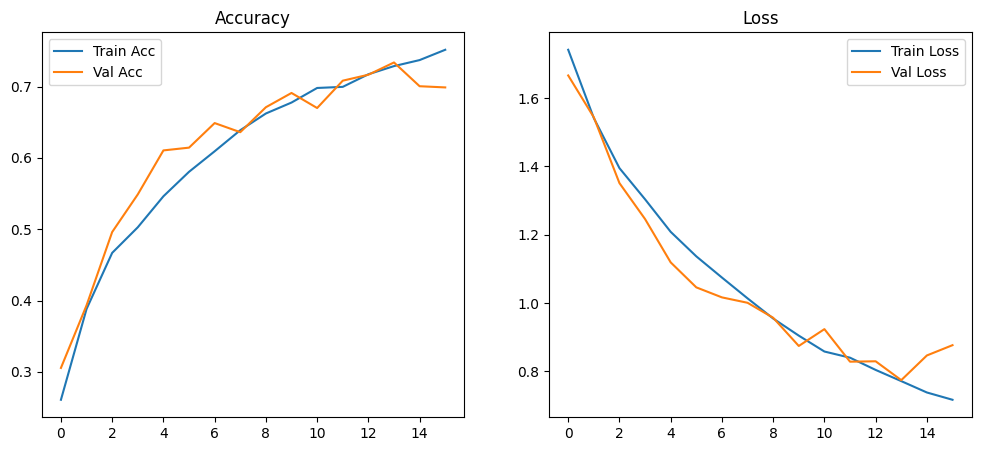

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 138s 8s/step
Classification Report:

                precision    recall  f1-score   support

  Baked Potato       0.80      0.69      0.74       100
        Burger       0.82      0.67      0.74       100
Crispy Chicken       0.70      0.84      0.76       100
         Fries       0.56      0.84      0.67       100
       Hot Dog       0.65      0.65      0.65       100
         Pizza       0.84      0.53      0.65       100

      accuracy                           0.70       600
     macro avg       0.73      0.70      0.70       600
  weighted avg       0.73      0.70      0.70       600



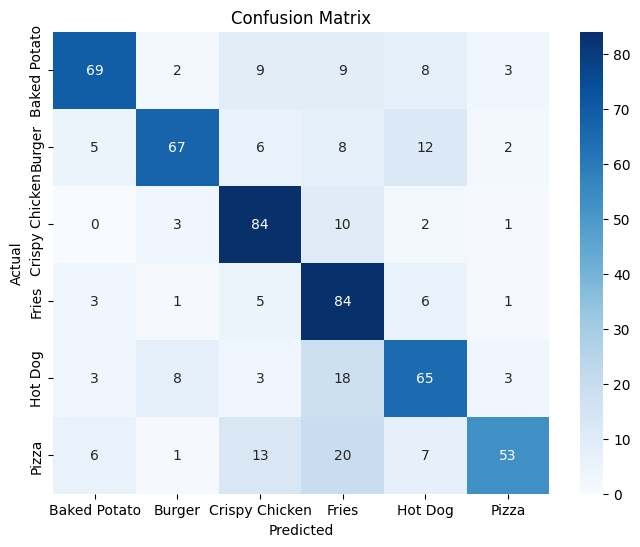

In [ ]:
# Predict test classes
pred_probs = model.predict(test_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Classification Report
print("Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


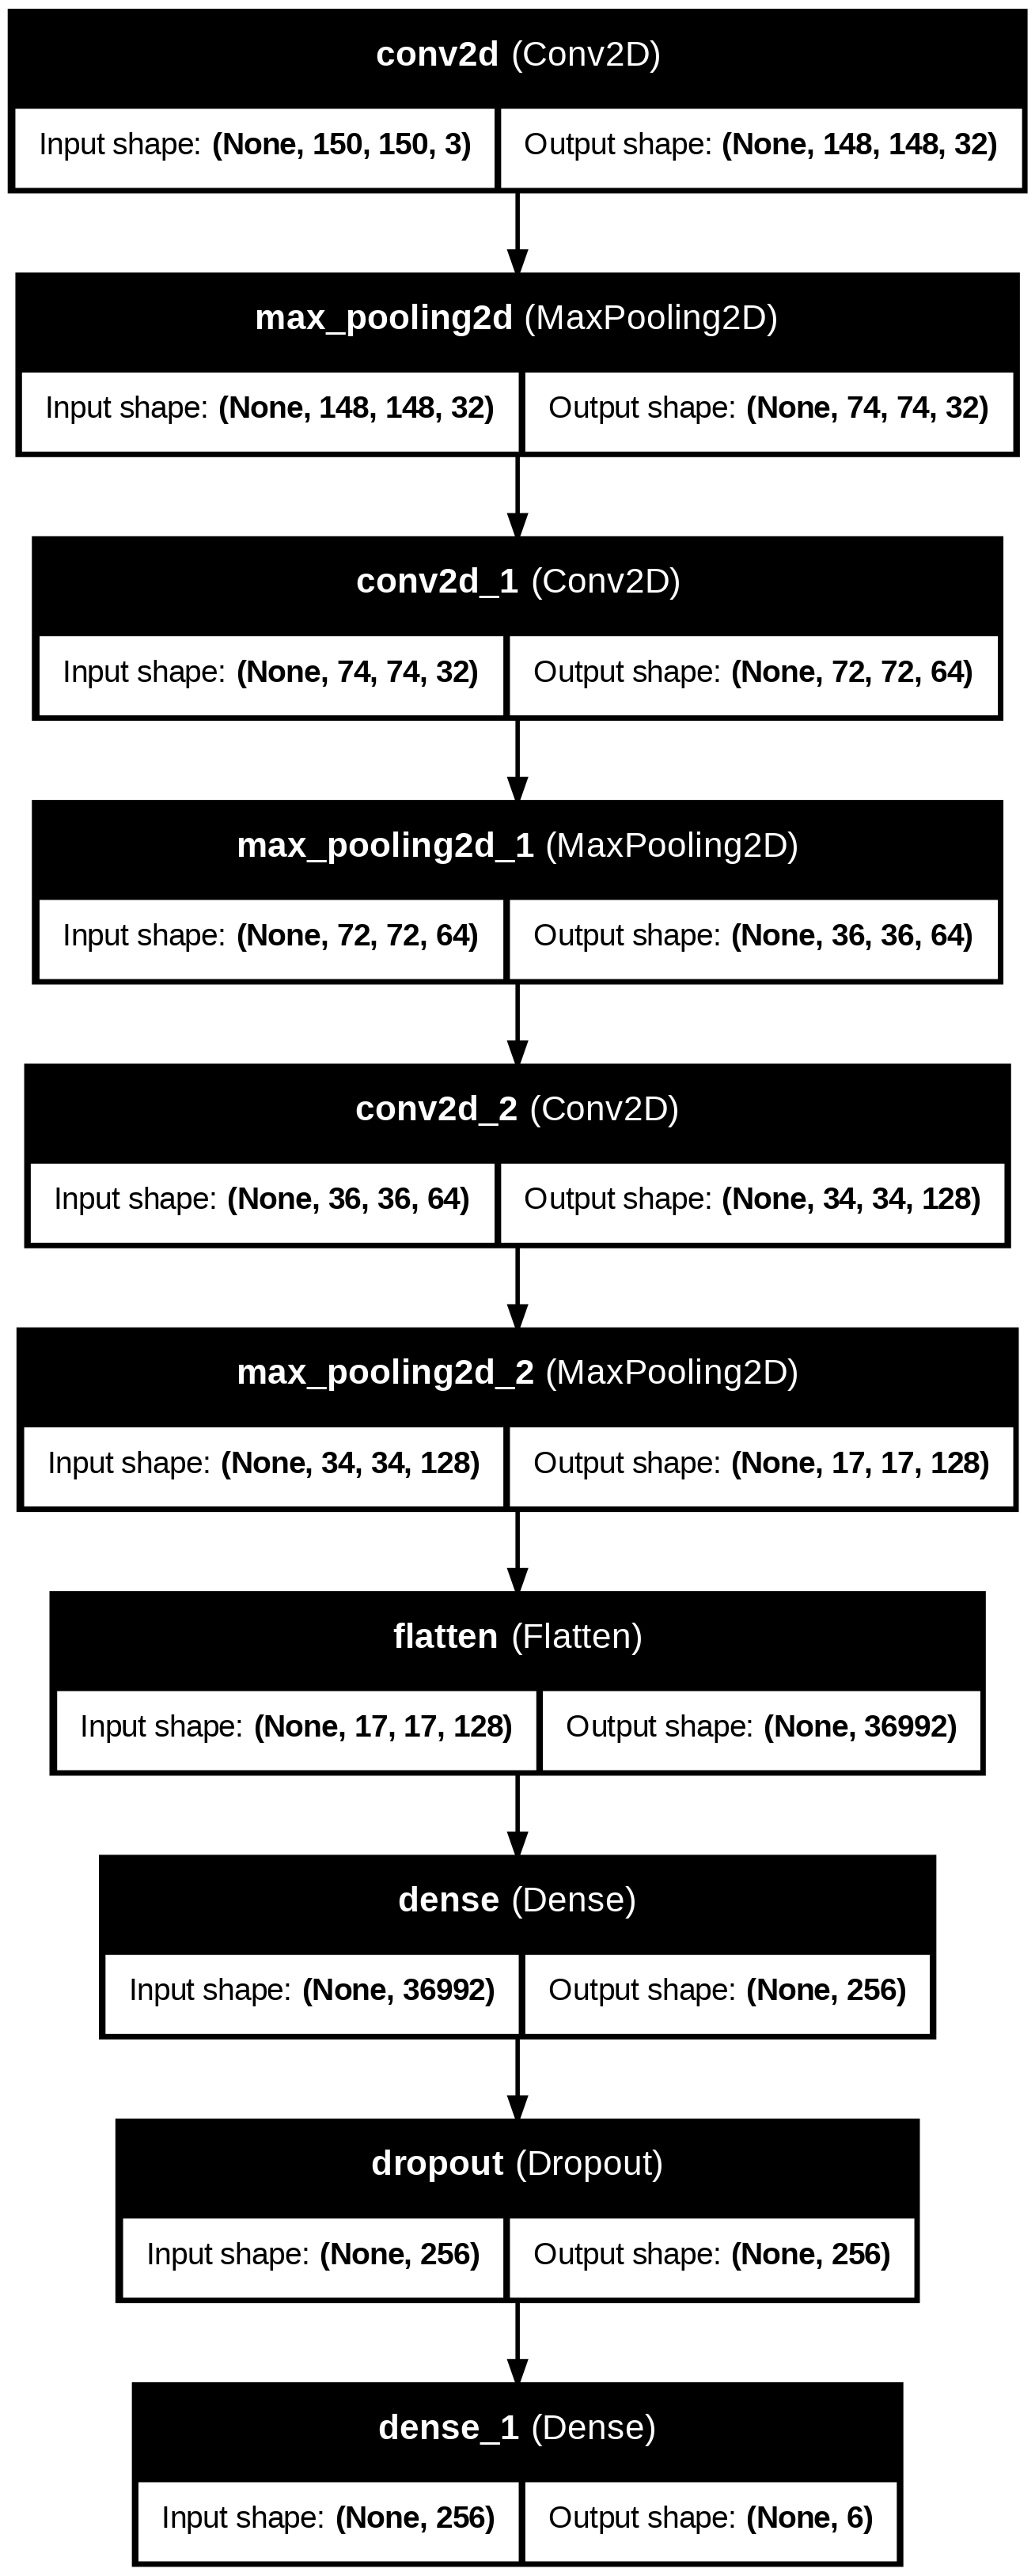

In [ ]:
from tensorflow.keras.utils import plot_model

# Save as PNG
plot_model(model, to_file="model_architecture.png", show_shapes=True, show_layer_names=True)


## **down part with result modified one**

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.savefig('/content/accuracy_plot.png')
plt.clf()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss over Epochs")
plt.savefig('/content/loss_plot.png')
plt.clf()


<Figure size 640x480 with 0 Axes>

19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 473ms/step


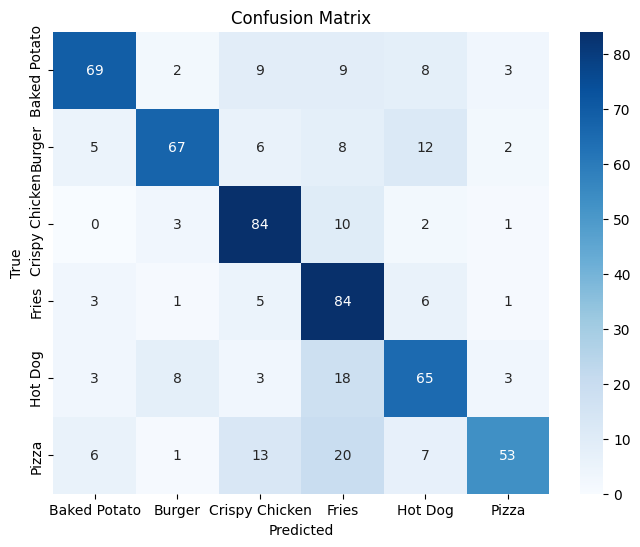

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Predict
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('/content/classification_report.csv')

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, xticklabels=class_labels, yticklabels=class_labels, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig('/content/confusion_matrix.png')


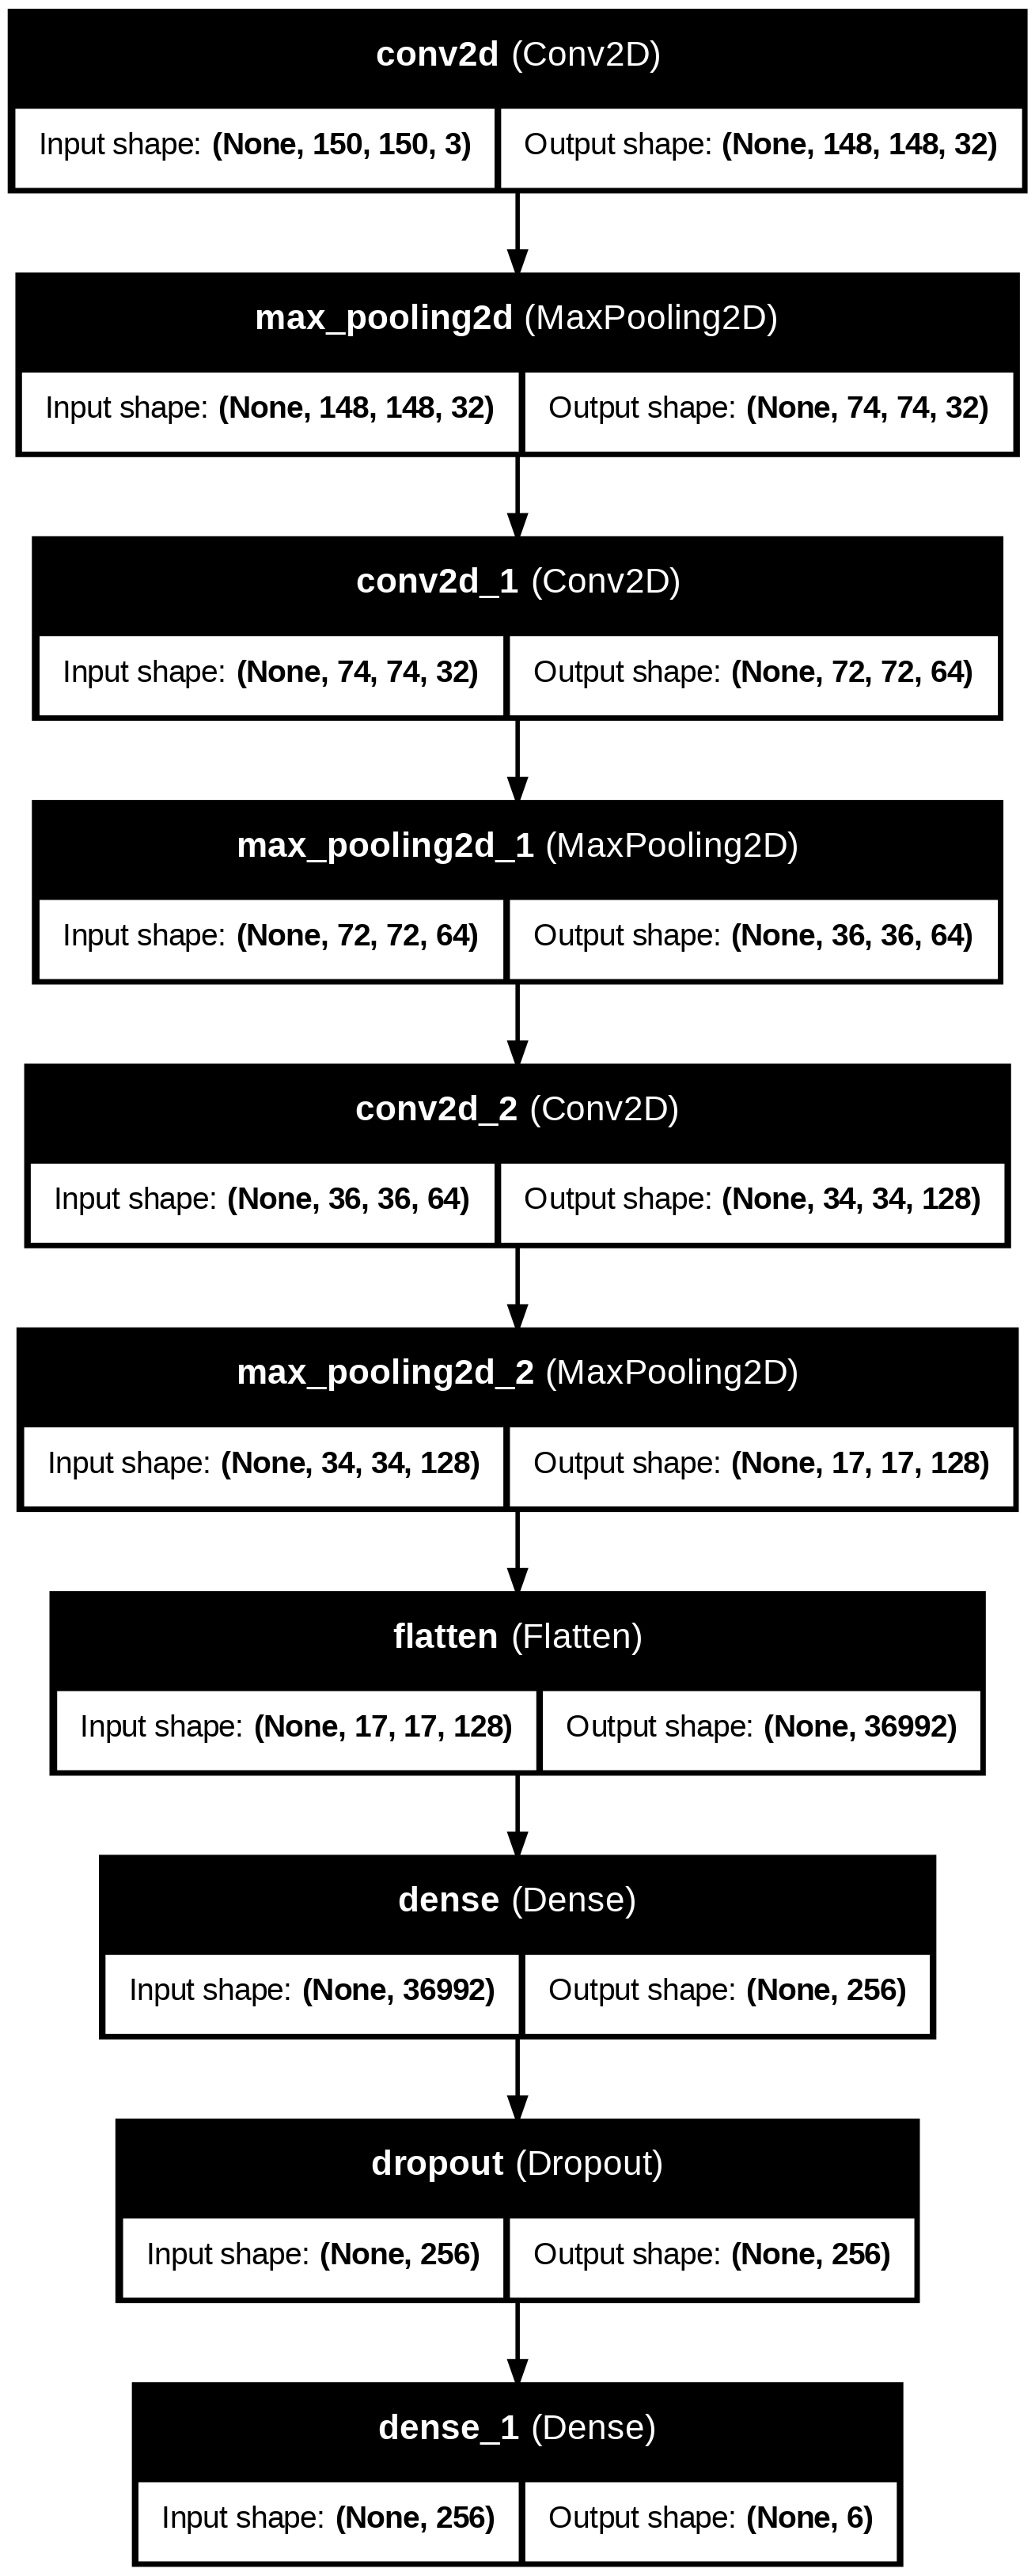

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='/content/model_architecture.png', show_shapes=True, show_layer_names=True)
